# Time series forecasting with ARIMA

In this notebook, we demonstrate how to:
- prepare time series data for training an ARIMA time series forecasting model
- implement a simple ARIMA model to forecast the next HORIZON steps ahead (time *t+1* through *t+HORIZON*) in the time series
- evaluate the model 


The data in this example is taken from the GEFCom2014 forecasting competition<sup>1</sup>. It consists of 3 years of hourly electricity load and temperature values between 2012 and 2014. The task is to forecast future values of electricity load. In this example, we show how to forecast one time step ahead, using historical load data only.

<sup>1</sup>Tao Hong, Pierre Pinson, Shu Fan, Hamidreza Zareipour, Alberto Troccoli and Rob J. Hyndman, "Probabilistic energy forecasting: Global Energy Forecasting Competition 2014 and beyond", International Journal of Forecasting, vol.32, no.3, pp 896-913, July-September, 2016.

In [ ]:
#pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from common.utils import load_data, mape
from IPython.display import Image

%matplotlib inline
pd.options.display.float_format = '{:,.2f}'.format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore") # specify to ignore warning messages

In [63]:
energy = load_data('./data')[['load']]
energy.head(10)

,load
2012-01-01 00:00:00,"2,698.00"
2012-01-01 01:00:00,"2,558.00"
2012-01-01 02:00:00,"2,444.00"
2012-01-01 03:00:00,"2,402.00"
2012-01-01 04:00:00,"2,403.00"
2012-01-01 05:00:00,"2,453.00"
2012-01-01 06:00:00,"2,560.00"
2012-01-01 07:00:00,"2,719.00"
2012-01-01 08:00:00,"2,916.00"
2012-01-01 09:00:00,"3,105.00"


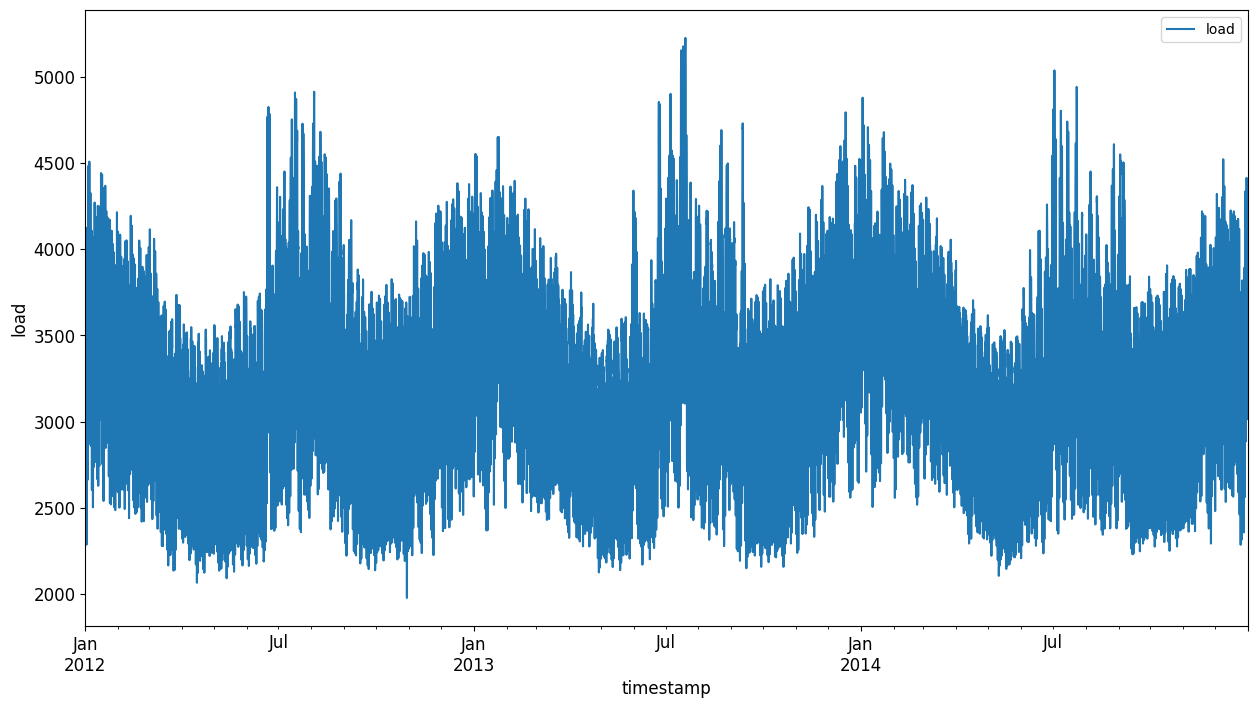

In [64]:
energy.plot(y='load', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

In [65]:
train_start_dt = '2014-11-01 00:00:00'
test_start_dt = '2014-12-30 00:00:00'

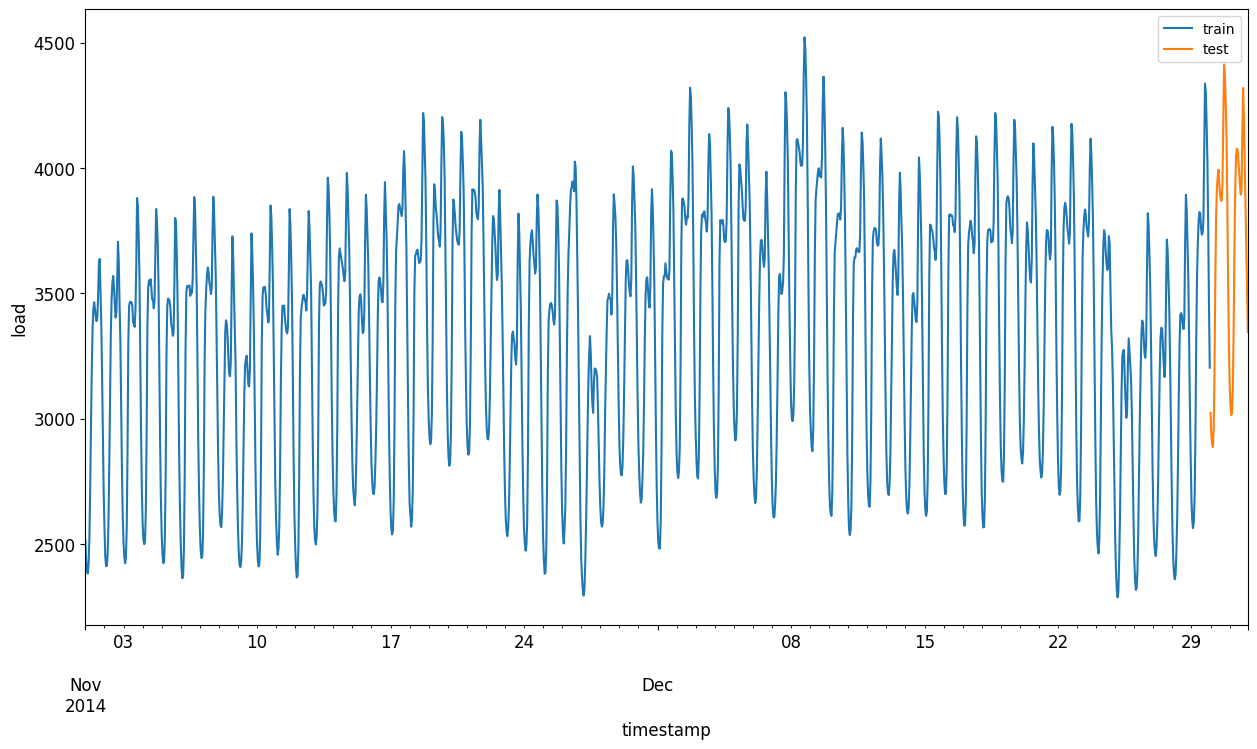

In [66]:
energy[(energy.index < test_start_dt) & (energy.index >= train_start_dt)][['load']].rename(columns={'load':'train'}) \
    .join(energy[test_start_dt:][['load']].rename(columns={'load':'test'}), how='outer') \
    .plot(y=['train', 'test'], figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

The above code is clever and compact, but unreadable hence rewriting it in a more readable format.(as suggested by gemini)

<Axes: >

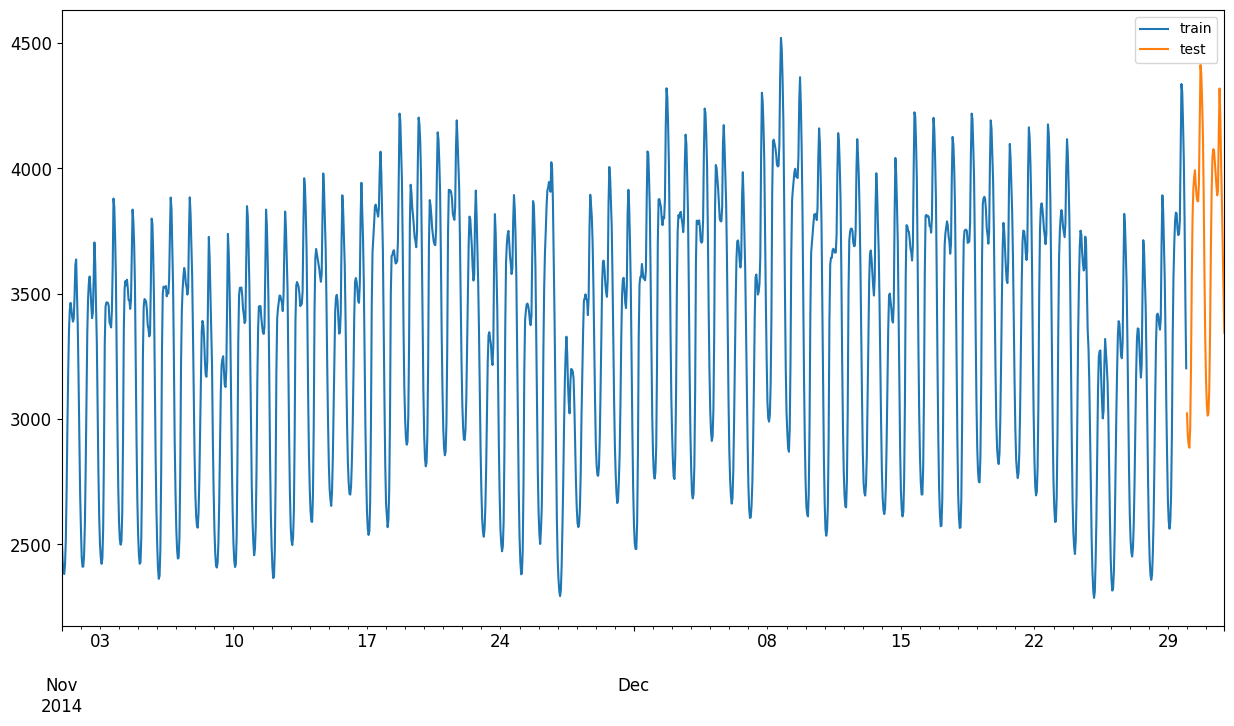

In [ ]:
# 1. Create the training set
# train_data = energy.loc[
#     (energy.index >= train_start_dt) & (energy.index < test_start_dt), 
#     ['load']
# ].rename(columns={'load': 'train'})

# # 2. Create the test set
# test_data = energy.loc[test_start_dt:, ['load']].rename(columns={'load': 'test'})

# # 3. Join them (outer join preserves all dates)
# combined_data = train_data.join(test_data, how='outer')

# # 4. Plot
# combined_data.plot(y=['train', 'test'], figsize=(15, 8), fontsize=12)


#### Why we have only train and test sets here and no validation sets ?
- Parameter Estimation: The statsmodels ARIMA.fit() function uses techniques like Maximum Likelihood Estimation (MLE) to find the best coefficients (𝑝,𝑑,𝑞) that explain the training data.
- Information Criteria: Instead of checking accuracy on a separate validation set, the model uses metrics like AIC (Akaike Information Criterion) or BIC (Bayesian Information Criterion). These formulas automatically penalize the model for being too complex, effectively doing the job of a validation set (preventing overfitting) without needing extra data.
- Residual Analysis: The "validation" step in ARIMA often involves checking the residuals (errors) of the fit to ensure they look like random noise (White Noise). If they don't, the model parameters are adjusted.

> In time series analysis, White Noise is a mathematical term for a sequence of data points that are completely random and unpredictable. The name is an analogy to "white light," which contains all visible frequencies at equal intensity; similarly, white noise contains all "frequencies" of randomness without any specific pattern. 
> White noise is used as a diagnostic "finish line" for your model. If residuals(prediction errors) are just White Noise, it means your model has successfully captured every possible pattern (trend, seasonality, etc.). All that is left is "pure randomness" that no model could ever predict. You can stop fitting; you’ve done a perfect job.


Filter the original dataset to include only the aforementioned time periods per set and only including the needed column 'load' plus the date:

In [67]:
# Create the actual datasets for training
train = energy.copy()[(energy.index >= train_start_dt) & (energy.index < test_start_dt)][['load']]
test = energy.copy()[energy.index >= test_start_dt][['load']]
print('energy data shape: ', energy.shape)
print('Training data shape: ', train.shape)
print('Test data shape: ', test.shape)

energy data shape:  (26304, 1)
Training data shape:  (1416, 1)
Test data shape:  (48, 1)


Scale the data to be in the range (0, 1).

In [68]:
scaler = MinMaxScaler()
train['load'] = scaler.fit_transform(train)
train.head(10)

,load
2014-11-01 00:00:00,0.10
2014-11-01 01:00:00,0.07
2014-11-01 02:00:00,0.05
2014-11-01 03:00:00,0.04
2014-11-01 04:00:00,0.06
2014-11-01 05:00:00,0.10
2014-11-01 06:00:00,0.19
2014-11-01 07:00:00,0.31
2014-11-01 08:00:00,0.40
2014-11-01 09:00:00,0.48


Visualize the original vs. scaled data:

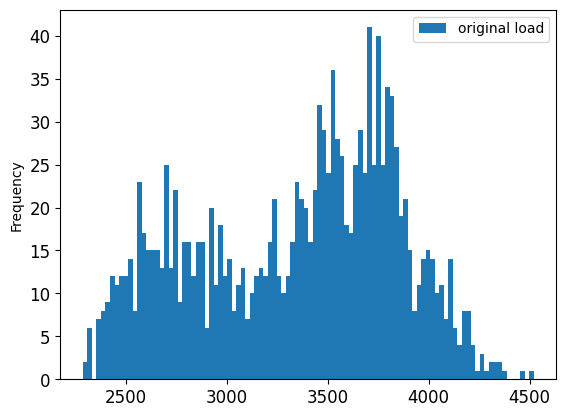

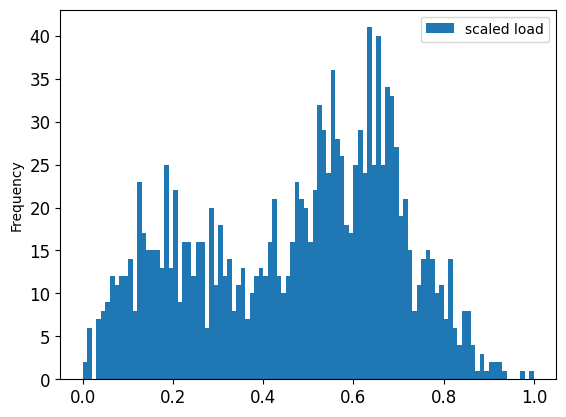

In [69]:
energy[(energy.index >= train_start_dt) & (energy.index < test_start_dt)][['load']].rename(columns={'load':'original load'}).plot.hist(bins=100, fontsize=12)
train.rename(columns={'load':'scaled load'}).plot.hist(bins=100, fontsize=12)
plt.show()

Scale the test data as well

In [70]:
test['load'] = scaler.transform(test)
test.head()

,load
2014-12-30 00:00:00,0.33
2014-12-30 01:00:00,0.29
2014-12-30 02:00:00,0.27
2014-12-30 03:00:00,0.27
2014-12-30 04:00:00,0.30


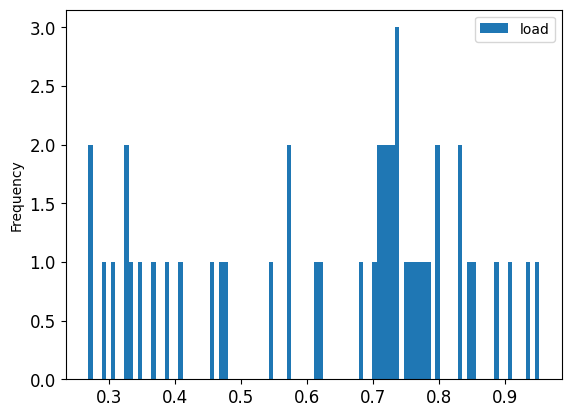

In [71]:
test.plot.hist(bins=100, fontsize=12)
plt.show()

#### Implement ARIMA
It's time to implement ARIMA! You'll now use the statsmodels library that you installed earlier.    
Now you need to follow several steps.  
- Define the model by calling SARIMAX() and passing in the model parameters: p, d, and q parameters, and P, D, and Q parameters.
- Prepare the model for the training data by calling the fit() function.
- Make predictions calling the forecast() function and specifying the number of steps (the horizon) to forecast.
> What are all these parameters for? In an ARIMA model there are 3 parameters that are used to help model the major aspects of a time series: seasonality, trend, and noise. These parameters are:    
 - p: the parameter associated with the auto-regressive aspect of the model, which incorporates past values.   
 - d: the parameter associated with the integrated part of the model, which affects the amount of differencing (🎓 remember differencing 👆?) to apply to a time series.
 - q: the parameter associated with the moving-average part of the model.

> Note: If your data has a seasonal aspect - which this one does - , we use a seasonal ARIMA model (SARIMA). In that case you need to use another set of parameters: P, D, and Q which describe the same associations as p, d, and q, but correspond to the seasonal components of the model.     

Start by setting your preferred horizon value. Let's try 3 hours:

In [72]:
# Specify the number of steps to forecast ahead
HORIZON = 3
print('Forecasting horizon:', HORIZON, 'hours')

Forecasting horizon: 3 hours


Selecting the best values for an ARIMA model's parameters can be challenging as it's somewhat subjective and time intensive. You might consider using an auto_arima() function from the pyramid library,    
For now try some manual selections to find a good model.

In [73]:
order = (4, 1, 0)
seasonal_order = (1, 1, 0, 24)

model = SARIMAX(endog=train, order=order, seasonal_order=seasonal_order)
results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                 1416
Model:             SARIMAX(4, 1, 0)x(1, 1, 0, 24)   Log Likelihood                3477.240
Date:                            Tue, 03 Mar 2026   AIC                          -6942.480
Time:                                    16:21:57   BIC                          -6911.054
Sample:                                11-01-2014   HQIC                         -6930.728
                                     - 12-29-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8410      0.016     52.160      0.000       0.809       0.873
ar.L2         -0.5226      0.034   

#### Evaluate your model
To evaluate your model, you can perform the so-called walk forward validation. In practice, time series models are re-trained each time a new data becomes available. This allows the model to make the best forecast at each time step.    
Starting at the beginning of the time series using this technique, train the model on the train data set. Then make a prediction on the next time step. The prediction is evaluated against the known value. The training set is then expanded to include the known value and the process is repeated.    
> Note: You should keep the training set window fixed for more efficient training so that every time you add a new observation to the training set, you remove the observation from the beginning of the set.   
This process provides a more robust estimation of how the model will perform in practice. However, it comes at the computation cost of creating so many models. This is acceptable if the data is small or if the model is simple, but could be an issue at scale.    
Walk-forward validation is the gold standard of time series model evaluation and is recommended for your own projects.   
1. First, create a test data point for each HORIZON step.

In [81]:
test_shifted = test.copy()
test_shifted.head()
for t in range(1, HORIZON):  # iterate from 1 to HORIZON -1ß
# # #     # add columns with values from the subsequent rows, -t (negative t) pulls data up from the next rows, freq=h means, find values from exactly 1 hour in the future, even if there are gaps in your data.
    test_shifted['load+'+str(t)] = test_shifted['load'].shift(-t, freq='h')
# # # # The above code will effectively add 3 new columns to test_shifted, namely load+1, load+2, load+3, with the values of load in the subsequent rows.
test_shifted = test_shifted.dropna(how='any') # this will remove the last 3 rows as ateast one of the 3 new columns will not have a value
print(f'''test_shifted shape {test_shifted.shape}''')
test_shifted.head()

test_shifted shape (46, 3)


,load,load+1,load+2
2014-12-30 00:00:00,0.33,0.29,0.27
2014-12-30 01:00:00,0.29,0.27,0.27
2014-12-30 02:00:00,0.27,0.27,0.30
2014-12-30 03:00:00,0.27,0.30,0.41
2014-12-30 04:00:00,0.30,0.41,0.57


2. Make predictions on your test data using this sliding window approach in a loop the size of the test data length:

In [80]:
print(f'''train shape {train.shape}''')
train.head()

train shape (1416, 1)


,load
2014-11-01 00:00:00,0.10
2014-11-01 01:00:00,0.07
2014-11-01 02:00:00,0.05
2014-11-01 03:00:00,0.04
2014-11-01 04:00:00,0.06


In [77]:
%%time
training_window = 720 # dedicate 30 days (720 hours) for training

train_ts = train['load']
test_ts = test_shifted
# history is the "Rolling Window" of all data available to the model at any specific moment in the simulation.

# Creating a python list to use for the walk-forward, and copy all the data from train_ts(a pandas dataframe)
# for each row in train_ts

history = [x for x in train_ts] 
history = history[(-training_window):] # take the last 720 rows.

predictions = list() # create a new list for predictions

order = (2, 1, 0) 
seasonal_order = (1, 1, 0, 24)

for t in range(test_ts.shape[0]):
    model = SARIMAX(endog=history, order=order, seasonal_order=seasonal_order)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps = HORIZON)
    predictions.append(yhat)
    obs = list(test_ts.iloc[t]) # take the next row from test_ts
    # move the training window
    history.append(obs[0]) # and append it to the window
    history.pop(0) # remove the first entry from the window, effectively moving the window forward by one entry into test_ts
    print(test_ts.index[t])
    print(t+1, ': predicted =', yhat, 'expected =', obs)

2014-12-30 00:00:00
1 : predicted = [0.32 0.29 0.28] expected = [0.32945389435989236, 0.2900626678603402, 0.2739480752014323]
2014-12-30 01:00:00
2 : predicted = [0.3  0.29 0.3 ] expected = [0.2900626678603402, 0.2739480752014323, 0.26812891674127126]
2014-12-30 02:00:00
3 : predicted = [0.27 0.28 0.32] expected = [0.2739480752014323, 0.26812891674127126, 0.3025962399283795]
2014-12-30 03:00:00
4 : predicted = [0.28 0.32 0.42] expected = [0.26812891674127126, 0.3025962399283795, 0.40823634735899716]
2014-12-30 04:00:00
5 : predicted = [0.3  0.39 0.54] expected = [0.3025962399283795, 0.40823634735899716, 0.5689346463742166]
2014-12-30 05:00:00
6 : predicted = [0.4  0.55 0.66] expected = [0.40823634735899716, 0.5689346463742166, 0.6799462846911368]
2014-12-30 06:00:00
7 : predicted = [0.57 0.68 0.75] expected = [0.5689346463742166, 0.6799462846911368, 0.7309758281110115]
2014-12-30 07:00:00
8 : predicted = [0.68 0.75 0.8 ] expected = [0.6799462846911368, 0.7309758281110115, 0.75111906893

3. Compare the predictions to the actual load:

In [78]:
len(predictions)

46

In [83]:
eval_df = pd.DataFrame(predictions, columns=['t+'+str(t) for t in range(1, HORIZON+1)])
print(f'''eval_df shape  {eval_df.shape}''')
print(eval_df.head())
eval_df['timestamp'] = test.index[0:len(test.index)-HORIZON+1]
print(f'''eval_df shape  {eval_df.shape}''')
print(eval_df.head())

# make timestamp as the index and 2 new columns, prediction - values from the 3 columns t+1, t+2 and t+3 consolidated , h - has one of the column name as value, t+1, t+2 and t+3.
eval_df = pd.melt(eval_df, id_vars='timestamp', value_name='prediction', var_name='h')
print(f'''\nAfter melt''')
print(f'''eval_df shape  {eval_df.shape}''')
print(eval_df.head())
print(f'''\ntest_ts shape {test_ts.shape}''')
print(f'''test_ts head \n{test_ts.head()}''')
test_transpose = np.array(np.transpose(test_ts))
print(f'''\ntest_transpose shape {test_transpose.shape}''')
print(f'''test_transpose head \n{test_transpose}''')

test_ravel = test_transpose.ravel()
print(f'''\ntest_ravel shape {test_ravel.shape}''')
print(f'''test_ravel head \n{test_ravel}''')
eval_df['actual'] = np.array(np.transpose(test_ts)).ravel() # as the total elements are 180 in the RHS this assignment is failing as the LHS has only 135 rows
# eval_df['actual'] = test_ravel[:135] # took a subset of the RHS above and assigned to LHS and this worked.
eval_df[['prediction', 'actual']] = scaler.inverse_transform(eval_df[['prediction', 'actual']])
eval_df.head()

eval_df shape  (46, 3)
   t+1  t+2  t+3
0 0.32 0.29 0.28
1 0.30 0.29 0.30
2 0.27 0.28 0.32
3 0.28 0.32 0.42
4 0.30 0.39 0.54
eval_df shape  (46, 4)
   t+1  t+2  t+3           timestamp
0 0.32 0.29 0.28 2014-12-30 00:00:00
1 0.30 0.29 0.30 2014-12-30 01:00:00
2 0.27 0.28 0.32 2014-12-30 02:00:00
3 0.28 0.32 0.42 2014-12-30 03:00:00
4 0.30 0.39 0.54 2014-12-30 04:00:00

After melt
eval_df shape  (138, 3)
            timestamp    h  prediction
0 2014-12-30 00:00:00  t+1        0.32
1 2014-12-30 01:00:00  t+1        0.30
2 2014-12-30 02:00:00  t+1        0.27
3 2014-12-30 03:00:00  t+1        0.28
4 2014-12-30 04:00:00  t+1        0.30

test_ts shape (46, 3)
test_ts head 
                     load  load+1  load+2
2014-12-30 00:00:00  0.33    0.29    0.27
2014-12-30 01:00:00  0.29    0.27    0.27
2014-12-30 02:00:00  0.27    0.27    0.30
2014-12-30 03:00:00  0.27    0.30    0.41
2014-12-30 04:00:00  0.30    0.41    0.57

test_transpose shape (3, 46)
test_transpose head 
[[0.33 0.29 0.27 0.2

,timestamp,h,prediction,actual
0,2014-12-30 00:00:00,t+1,"3,009.04","3,023.00"
1,2014-12-30 01:00:00,t+1,"2,955.69","2,935.00"
2,2014-12-30 02:00:00,t+1,"2,900.14","2,899.00"
3,2014-12-30 03:00:00,t+1,"2,917.79","2,886.00"
4,2014-12-30 04:00:00,t+1,"2,947.42","2,963.00"


#### Check model accuracy
Check the accuracy of your model by testing its mean absolute percentage error (MAPE) over all the predictions.   
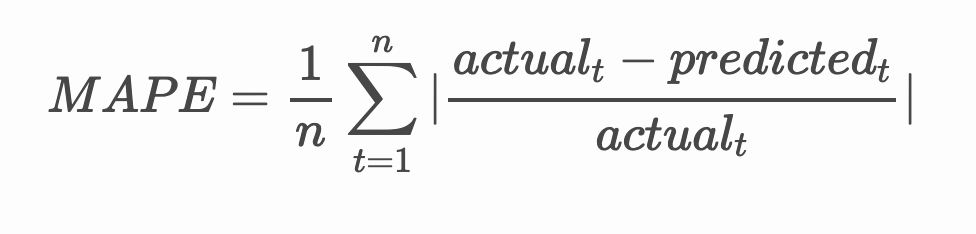
MAPE is used to show prediction accuracy as a ratio defined by the above formula. The difference between actualt and predictedt is divided by the actualt. "The absolute value in this calculation is summed for every forecasted point in time and divided by the number of fitted points n." wikipedia.  

1. Express equation in code:

In [84]:
if(HORIZON > 1):
    eval_df['APE'] = (eval_df['prediction'] - eval_df['actual']).abs() / eval_df['actual']
    print(eval_df.groupby('h')['APE'].mean())

h
t+1   0.01
t+2   0.01
t+3   0.02
Name: APE, dtype: float64


2. Calculate one step's MAPE:

In [85]:
print('One step forecast MAPE: ', (mape(eval_df[eval_df['h'] == 't+1']['prediction'], eval_df[eval_df['h'] == 't+1']['actual']))*100, '%')

One step forecast MAPE:  0.5568325878399967 %


3. Print the multi-step forecast MAPE:

In [86]:
print('Multi-step forecast MAPE: ', mape(eval_df['prediction'], eval_df['actual'])*100, '%')

Multi-step forecast MAPE:  1.144374544938895 %


A nice low number is best: consider that a forecast that has a MAPE of 10 is off by 10%.   
4. But as always, it's easier to see this kind of accuracy measurement visually, so let's plot it:   

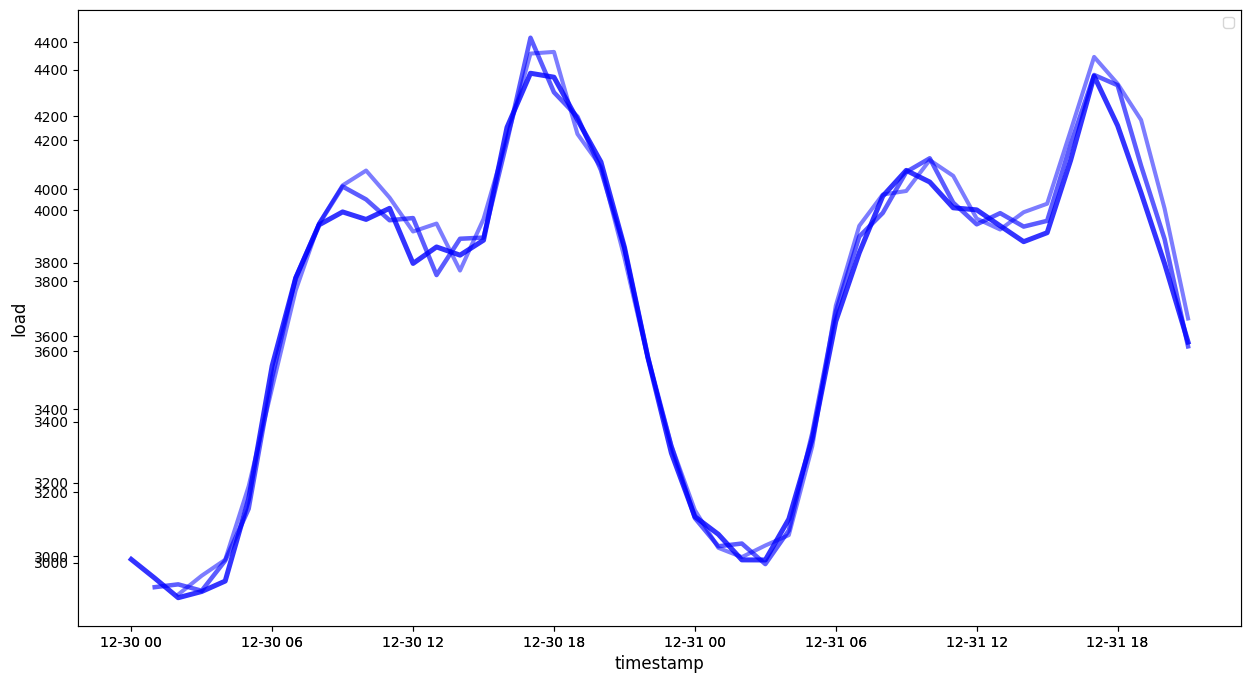

In [88]:
if(HORIZON == 1):
    ## Plotting single step forecast
    eval_df.plot(x='timestamp', y=['actual', 'prediction'], style=['r', 'b'], figsize=(15, 8))

else:
    ## Plotting multi step forecast
    plot_df = eval_df[(eval_df.h=='t+1')][['timestamp', 'actual']]
    for t in range(1, HORIZON+1):
        plot_df['t+'+str(t)] = eval_df[(eval_df.h=='t+'+str(t))]['prediction'].values

    fig = plt.figure(figsize=(15, 8))
    ax = plt.plot(plot_df['timestamp'], plot_df['actual'], color='red', linewidth=4.0)
    ax = fig.add_subplot(111)
    for t in range(1, HORIZON+1):
        x = plot_df['timestamp'][(t-1):]
        y = plot_df['t+'+str(t)][0:len(x)]
        ax.plot(x, y, color='blue', linewidth=4*math.pow(.9,t), alpha=math.pow(0.8,t))

    ax.legend(loc='best')

plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

#### 🚀Challenge
Dig into the ways to test the accuracy of a Time Series Model. We touch on MAPE in this lesson, but are there other methods you could use? Research them and annotate them. A helpful document can be found [here](https://otexts.com/fpp2/accuracy.html).   
Explore some other models and techniques for time series forecasting [here](https://microsoft.github.io/forecasting/)